In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("movies.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset Shape: (2000, 7)


,budget,revenue,popularity,runtime,vote_average,title,genres
0,57755036,107323371,60.377360,98,6.611888,Movie 1,"[{'id': 10749, 'name': 'Romance'}]"
1,192100010,342896533,86.289857,96,7.184687,Movie 2,"[{'id': 18, 'name': 'Drama'}]"
2,128521863,253206827,86.995324,148,3.542978,Movie 3,"[{'id': 35, 'name': 'Comedy'}]"
3,156299516,89635602,72.710096,118,5.985176,Movie 4,"[{'id': 18, 'name': 'Drama'}]"
4,148532820,221133868,74.829585,161,4.578480,Movie 5,"[{'id': 35, 'name': 'Comedy'}]"


# STAGE 0: Problem Statement

### 1. What makes a movie successful?

In this project, a movie is considered successful when its revenue is greater than its budget.

**Rule:**
- Success = 1 if Revenue > Budget
- Success = 0 if Revenue <= Budget

### 2. Why is predicting film success valuable?

Predicting movie success helps stakeholders make better financial decisions.

- **Movie Studios:** It can help studios decide which movies are worth producing and investing in.
- **Investors:** It can help investors estimate the risk and potential success of investing in a movie.

### 3. Objective of the Project

The objective of MovieIQ is to analyse movie data and build a machine learning model that predicts whether a movie will be successful.

The main steps are:
1. Clean and prepare the movie dataset.
2. Perform exploratory data analysis and visualisation.
3. Conduct statistical tests.
4. Train and evaluate a Random Forest classification model.
5. Build an interactive Streamlit dashboard.

### 4. Why is this a classification problem?

This is a classification problem because the model predicts one of two categories: successful or unsuccessful.

The target variable is **success**, where:
- 1 = Successful
- 0 = Unsuccessful

# STAGE 1: Data Preparation

In [4]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Number of Rows: 2000
Number of Columns: 7

Column Names:
['budget', 'revenue', 'popularity', 'runtime', 'vote_average', 'title', 'genres']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   budget        2000 non-null   int64  
 1   revenue       2000 non-null   int64  
 2   popularity    2000 non-null   float64
 3   runtime       2000 non-null   int64  
 4   vote_average  2000 non-null   float64
 5   title         2000 non-null   object 
 6   genres        2000 non-null   object 
dtypes: float64(2), int64(3), object(2)
memory usage: 109.5+ KB


In [5]:
df.describe()

,budget,revenue,popularity,runtime,vote_average
count,2.000000e+03,2.000000e+03,2000.000000,2000.000000,2000.000000
mean,1.019211e+08,1.780574e+08,50.090738,129.568000,6.036764
std,5.682795e+07,1.293879e+08,28.482104,28.906507,1.743093
min,1.070640e+06,1.138729e+06,1.018466,80.000000,3.008133
25%,5.274832e+07,7.458306e+07,25.720784,104.000000,4.583298
50%,1.026023e+08,1.484882e+08,50.210396,130.000000,6.052901
75%,1.507962e+08,2.623679e+08,74.925354,155.000000,7.577305
max,1.999879e+08,5.744901e+08,99.764659,179.000000,8.998509


In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
budget          0
revenue         0
popularity      0
runtime         0
vote_average    0
title           0
genres          0
dtype: int64


In [7]:
print("Movies with zero budget:", (df["budget"] == 0).sum())
print("Movies with zero revenue:", (df["revenue"] == 0).sum())

Movies with zero budget: 0
Movies with zero revenue: 0


### Missing and Zero Value Handling

The dataset was checked for missing values and zero values in budget and revenue.

A budget or revenue of 0 can represent missing or unreliable financial information and may incorrectly affect the success label. Such rows should be removed before further analysis.

In [8]:
df = df[(df["budget"] > 0) & (df["revenue"] > 0)].copy()

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (2000, 7)


In [9]:
df["success"] = (df["revenue"] > df["budget"]).astype(int)

df[["title", "budget", "revenue", "success"]].head(10)

,title,budget,revenue,success
0,Movie 1,57755036,107323371,1
1,Movie 2,192100010,342896533,1
2,Movie 3,128521863,253206827,1
3,Movie 4,156299516,89635602,0
4,Movie 5,148532820,221133868,1
5,Movie 6,134224038,270524761,1
6,Movie 7,36788921,73368473,1
7,Movie 8,134120466,332939335,1
8,Movie 9,161953558,346179511,1
9,Movie 10,94410762,281375537,1


In [10]:
success_counts = df["success"].value_counts()
success_percentage = df["success"].value_counts(normalize=True) * 100

print("Movie Counts:")
print(success_counts)

print("\nPercentage:")
print(success_percentage.round(2))

Movie Counts:
success
1    1614
0     386
Name: count, dtype: int64

Percentage:
success
1    80.7
0    19.3
Name: proportion, dtype: float64


### Success Distribution

A movie is labelled as successful (`success = 1`) when its revenue is greater than its budget. Otherwise, it is labelled unsuccessful (`success = 0`).

- Successful movies: 1614 (80.7%)
- Unsuccessful movies: 386 (19.3%)

The dataset is imbalanced because successful movies make up a much larger proportion of the dataset than unsuccessful movies.

In [11]:
df[["title", "genres"]].head(10)

,title,genres
0,Movie 1,"[{'id': 10749, 'name': 'Romance'}]"
1,Movie 2,"[{'id': 18, 'name': 'Drama'}]"
2,Movie 3,"[{'id': 35, 'name': 'Comedy'}]"
3,Movie 4,"[{'id': 18, 'name': 'Drama'}]"
4,Movie 5,"[{'id': 35, 'name': 'Comedy'}]"
5,Movie 6,"[{'id': 10749, 'name': 'Romance'}]"
6,Movie 7,"[{'id': 12, 'name': 'Adventure'}]"
7,Movie 8,"[{'id': 28, 'name': 'Action'}]"
8,Movie 9,"[{'id': 27, 'name': 'Horror'}]"
9,Movie 10,"[{'id': 27, 'name': 'Horror'}]"


In [12]:
def extract_genres(value):
    try:
        genres = ast.literal_eval(value)
        return [genre["name"] for genre in genres]
    except:
        return []

df["genre_list"] = df["genres"].apply(extract_genres)

df[["title", "genres", "genre_list"]].head(10)

,title,genres,genre_list
0,Movie 1,"[{'id': 10749, 'name': 'Romance'}]",[Romance]
1,Movie 2,"[{'id': 18, 'name': 'Drama'}]",[Drama]
2,Movie 3,"[{'id': 35, 'name': 'Comedy'}]",[Comedy]
3,Movie 4,"[{'id': 18, 'name': 'Drama'}]",[Drama]
4,Movie 5,"[{'id': 35, 'name': 'Comedy'}]",[Comedy]
5,Movie 6,"[{'id': 10749, 'name': 'Romance'}]",[Romance]
6,Movie 7,"[{'id': 12, 'name': 'Adventure'}]",[Adventure]
7,Movie 8,"[{'id': 28, 'name': 'Action'}]",[Action]
8,Movie 9,"[{'id': 27, 'name': 'Horror'}]",[Horror]
9,Movie 10,"[{'id': 27, 'name': 'Horror'}]",[Horror]


In [13]:
genre_df = df.explode("genre_list")

genre_df[["title", "genre_list", "success"]].head(10)

,title,genre_list,success
0,Movie 1,Romance,1
1,Movie 2,Drama,1
2,Movie 3,Comedy,1
3,Movie 4,Drama,0
4,Movie 5,Comedy,1
5,Movie 6,Romance,1
6,Movie 7,Adventure,1
7,Movie 8,Action,1
8,Movie 9,Horror,1
9,Movie 10,Horror,1


In [14]:
print("Number of unique genres:", genre_df["genre_list"].nunique())

print("\nGenres:")
print(sorted(genre_df["genre_list"].dropna().unique()))

Number of unique genres: 9

Genres:
['Action', 'Adventure', 'Animation', 'Comedy', 'Drama', 'Horror', 'Romance', 'Science Fiction', 'Thriller']


### Genre Processing

The `genres` column can contain multiple genres for a single movie. The genre names were extracted and stored as lists in a new `genre_list` column.

An exploded dataset called `genre_df` was also created so that each genre can be analysed separately. This makes the data suitable for genre-based filtering, visualisation, success-rate analysis, and statistical testing.

# STAGE 2: Exploratory Data Analysis

In [15]:
os.makedirs("assets", exist_ok=True)

print("Assets folder created successfully!")

Assets folder created successfully!


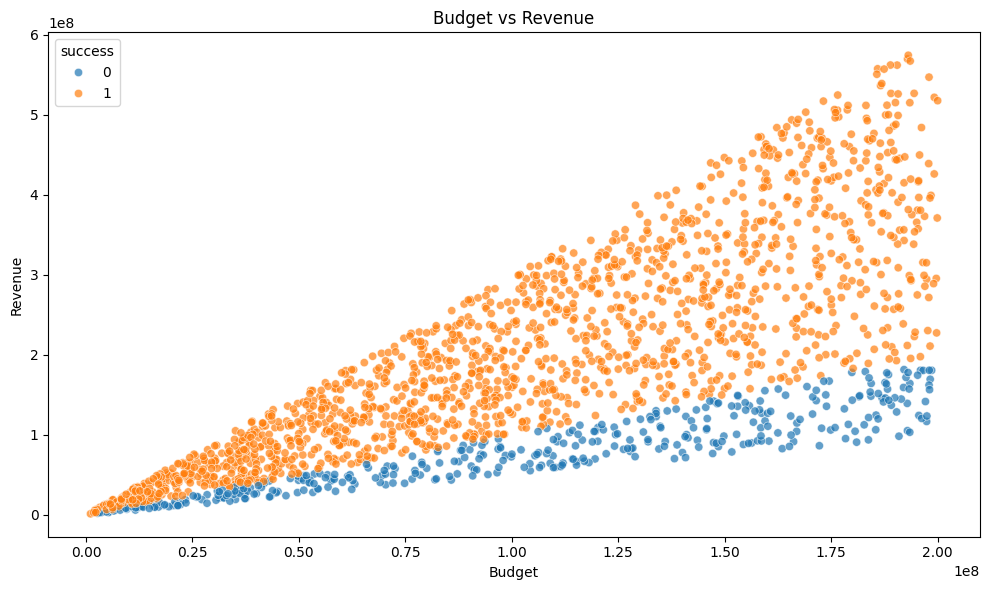

In [16]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="budget",
    y="revenue",
    hue="success",
    alpha=0.7
)

plt.title("Budget vs Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")

plt.tight_layout()
plt.savefig("assets/budget_vs_revenue.png", dpi=300)
plt.show()

In [17]:
budget_revenue_corr = df["budget"].corr(df["revenue"])

print("Correlation between Budget and Revenue:")
print(round(budget_revenue_corr, 3))

Correlation between Budget and Revenue:
0.76


### Budget vs Revenue Analysis

The correlation between budget and revenue is **0.76**, which indicates a strong positive relationship.

The scatter plot shows that movies with higher budgets generally tend to earn higher revenues. However, a higher budget does not guarantee success, as there is still variation in the revenue earned by individual movies.

Therefore, budget and revenue are strongly positively associated in this dataset.

In [18]:
genre_counts = genre_df["genre_list"].value_counts()

print("Number of Movies by Genre:")
print(genre_counts)

Number of Movies by Genre:
genre_list
Romance            220
Adventure          207
Science Fiction    205
Animation          203
Comedy             202
Horror             199
Drama              197
Thriller           194
Action             192
Name: count, dtype: int64


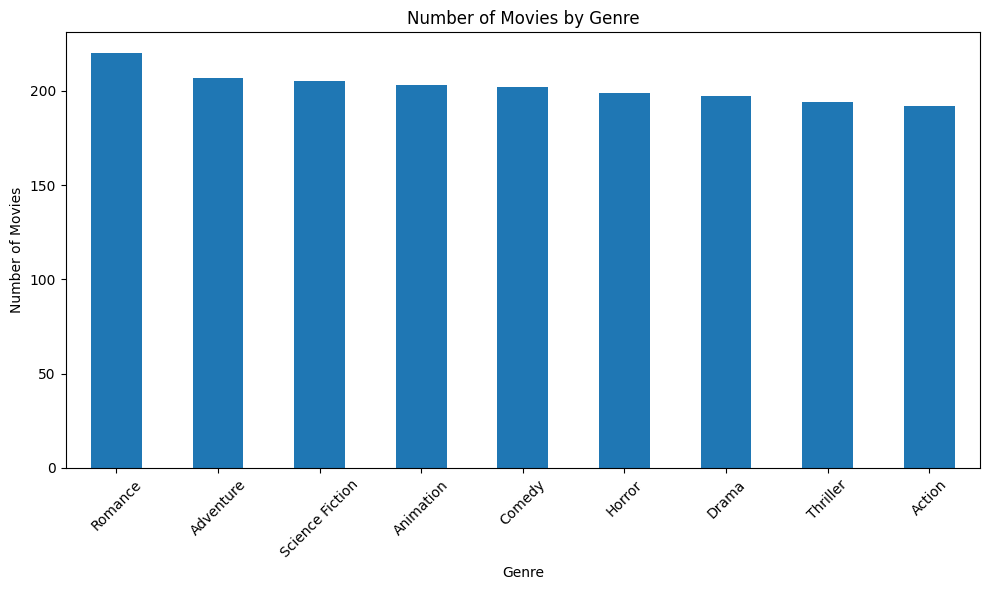

In [19]:
plt.figure(figsize=(10, 6))

genre_counts.plot(kind="bar")

plt.title("Number of Movies by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("assets/genre_frequency.png", dpi=300)
plt.show()

### Genre Frequency Analysis

Romance is the most common genre in the dataset with 220 movies, followed by Adventure with 207 and Science Fiction with 205 movies.

The genre distribution is relatively close across the different genres, although Romance appears most frequently.

In [20]:
genre_success = (
    genre_df.groupby("genre_list")["success"]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

genre_success["success_rate"] = genre_success["mean"] * 100

print(
    genre_success[
        ["count", "sum", "success_rate"]
    ].round(2)
)

                 count  sum  success_rate
genre_list                               
Drama              197  162         82.23
Horror             199  163         81.91
Animation          203  165         81.28
Comedy             202  164         81.19
Thriller           194  157         80.93
Romance            220  178         80.91
Adventure          207  166         80.19
Action             192  151         78.65
Science Fiction    205  161         78.54


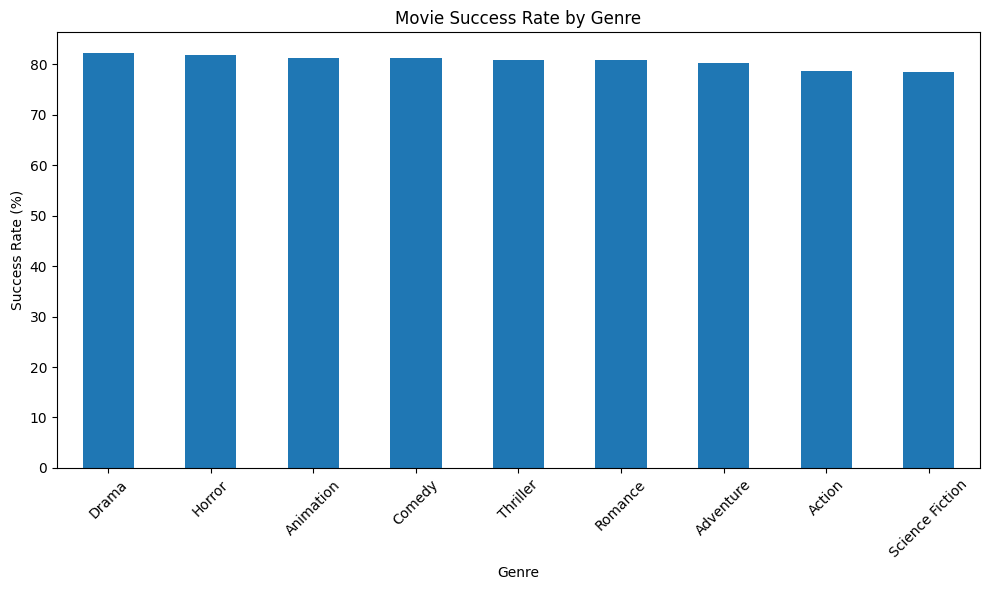

In [21]:
plt.figure(figsize=(10, 6))

genre_success["success_rate"].plot(kind="bar")

plt.title("Movie Success Rate by Genre")
plt.xlabel("Genre")
plt.ylabel("Success Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("assets/genre_success.png", dpi=300)
plt.show()

### Genre Success Analysis

Drama has the highest success rate at **82.23%**, followed by Horror at **81.91%** and Animation at **81.28%**.

Science Fiction has the lowest success rate at **78.54%**, followed by Action at **78.65%**.

Although the success rates vary by genre, the differences are relatively small, with all genres having success rates of approximately 79% to 82%.

In [22]:
feature_comparison = df.groupby("success")[
    ["popularity", "runtime", "vote_average"]
].mean()

print("Average Feature Values by Success:")
print(feature_comparison.round(2))

Average Feature Values by Success:
         popularity  runtime  vote_average
success                                   
0             47.40   131.62          6.12
1             50.73   129.08          6.02


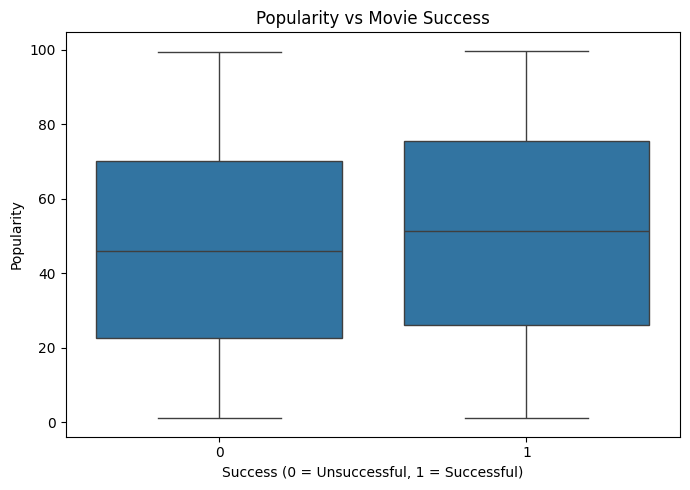

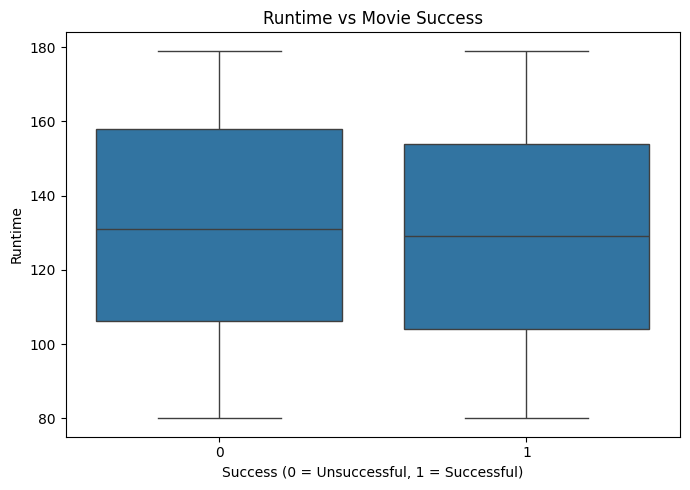

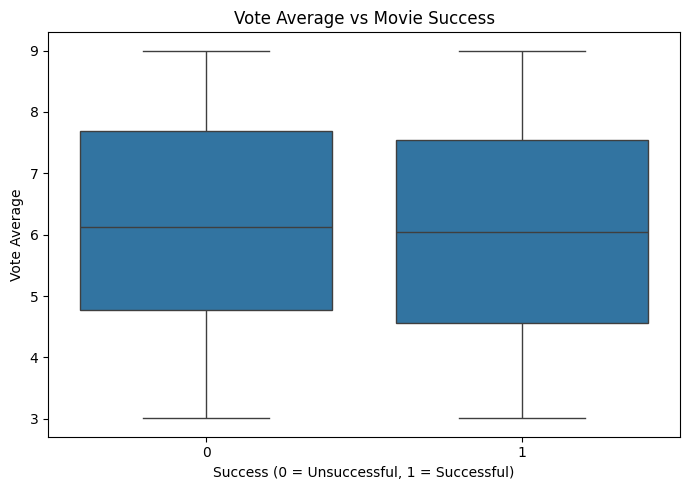

In [23]:
features = ["popularity", "runtime", "vote_average"]

for feature in features:
    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x="success",
        y=feature
    )

    plt.title(f"{feature.replace('_', ' ').title()} vs Movie Success")
    plt.xlabel("Success (0 = Unsuccessful, 1 = Successful)")
    plt.ylabel(feature.replace("_", " ").title())

    plt.tight_layout()
    plt.savefig(f"assets/{feature}_vs_success.png", dpi=300)
    plt.show()

### Popularity, Runtime and Vote Average vs Success

The average popularity of successful movies is **50.73**, compared with **47.40** for unsuccessful movies. This suggests that popularity may have a positive association with movie success.

The average runtime is **129.08 minutes** for successful movies and **131.62 minutes** for unsuccessful movies, showing only a small difference.

The average vote rating is also very similar, with **6.02** for successful movies and **6.12** for unsuccessful movies.

Among these three features, **popularity appears to show the clearest association with success**, although statistical testing is required to determine whether the difference is statistically significant.

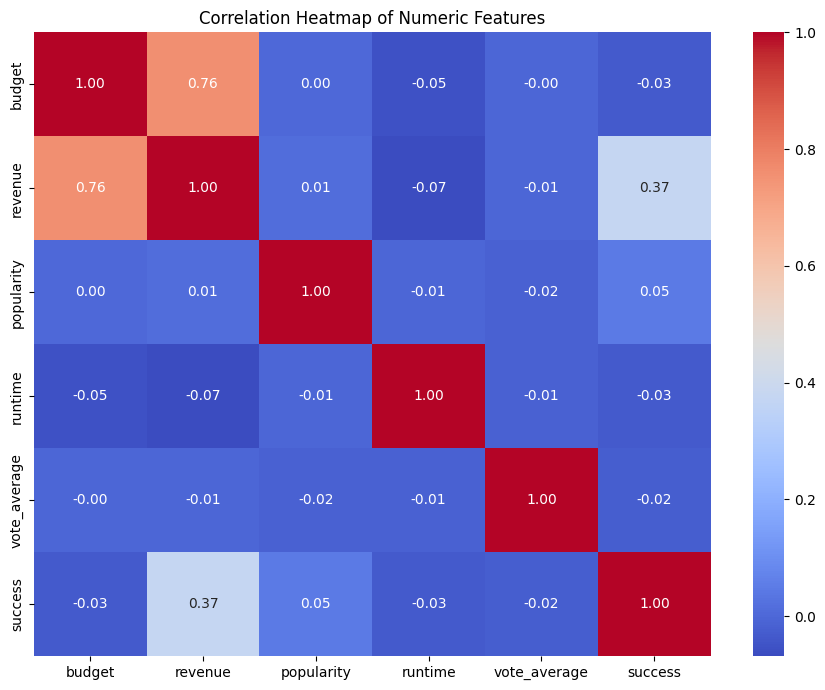

              budget  revenue  popularity  runtime  vote_average  success
budget          1.00     0.76        0.00    -0.05         -0.00    -0.03
revenue         0.76     1.00        0.01    -0.07         -0.01     0.37
popularity      0.00     0.01        1.00    -0.01         -0.02     0.05
runtime        -0.05    -0.07       -0.01     1.00         -0.01    -0.03
vote_average   -0.00    -0.01       -0.02    -0.01          1.00    -0.02
success        -0.03     0.37        0.05    -0.03         -0.02     1.00


In [24]:
numeric_columns = [
    "budget",
    "revenue",
    "popularity",
    "runtime",
    "vote_average",
    "success"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numeric Features")

plt.tight_layout()
plt.savefig("assets/correlation_heatmap.png", dpi=300)
plt.show()

print(correlation_matrix.round(2))

# STAGE 3: Statistical Testing

## 3.1 T-Test: Popularity and Movie Success

**Null Hypothesis (H0):** There is no significant difference in the mean popularity of successful and unsuccessful movies.

**Alternative Hypothesis (H1):** There is a significant difference in the mean popularity of successful and unsuccessful movies.

The significance level used is **0.05 (5%)**.

In [25]:
from scipy.stats import ttest_ind

successful_popularity = df[df["success"] == 1]["popularity"]
unsuccessful_popularity = df[df["success"] == 0]["popularity"]

t_stat, p_value = ttest_ind(
    successful_popularity,
    unsuccessful_popularity,
    equal_var=False
)

print("T-Statistic:", round(t_stat, 4))
print("P-Value:", round(p_value, 6))

if p_value < 0.05:
    print("Result: Reject the null hypothesis (H0)")
    print("Conclusion: There is a statistically significant difference in popularity.")
else:
    print("Result: Fail to reject the null hypothesis (H0)")
    print("Conclusion: There is no statistically significant difference in popularity.")

T-Statistic: 2.0617
P-Value: 0.039682
Result: Reject the null hypothesis (H0)
Conclusion: There is a statistically significant difference in popularity.


### T-Test Result and Conclusion

The T-Test produced:

- **T-Statistic:** 2.0617
- **P-Value:** 0.039682
- **Significance Level:** 0.05

Since the p-value (0.039682) is less than 0.05, the null hypothesis is rejected.

Therefore, there is a **statistically significant difference in popularity between successful and unsuccessful movies**.

## 3.2 Chi-Square Test: Genre and Movie Success

**Null Hypothesis (H0):** Genre and movie success are independent. There is no significant association between them.

**Alternative Hypothesis (H1):** Genre and movie success are associated.

The significance level used is **0.05 (5%)**.

In [26]:
from scipy.stats import chi2_contingency

# Create contingency table
contingency_table = pd.crosstab(
    genre_df["genre_list"],
    genre_df["success"]
)

print("Contingency Table:")
print(contingency_table)

# Perform Chi-Square test
chi2, p_value_chi, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Square Statistic:", round(chi2, 4))
print("P-Value:", round(p_value_chi, 6))
print("Degrees of Freedom:", dof)

if p_value_chi < 0.05:
    print("Result: Reject the null hypothesis (H0)")
    print("Conclusion: Genre is significantly associated with movie success.")
else:
    print("Result: Fail to reject the null hypothesis (H0)")
    print("Conclusion: There is no significant association between genre and movie success.")

Contingency Table:
success           0    1
genre_list              
Action           41  151
Adventure        41  166
Animation        38  165
Comedy           38  164
Drama            35  162
Horror           36  163
Romance          42  178
Science Fiction  44  161
Thriller         37  157

Chi-Square Statistic: 1.7356
P-Value: 0.988072
Degrees of Freedom: 8
Result: Fail to reject the null hypothesis (H0)
Conclusion: There is no significant association between genre and movie success.


### Chi-Square Test Result and Conclusion

The Chi-Square test produced:

- **Chi-Square Statistic:** 1.7356
- **P-Value:** 0.988072
- **Degrees of Freedom:** 8
- **Significance Level:** 0.05

Since the p-value (0.988072) is greater than 0.05, we fail to reject the null hypothesis.

Therefore, there is **no statistically significant association between genre and movie success** in this dataset.

## 3.3 Understanding the P-Value

A p-value helps us determine whether the observed result provides enough evidence against the null hypothesis.

In this project, a significance level of **0.05 (5%)** is used.

- If **p-value < 0.05**, the result is considered statistically significant and the null hypothesis is rejected.
- If **p-value >= 0.05**, there is not enough evidence to reject the null hypothesis.

A threshold of 0.05 is commonly used in statistical analysis to allow a 5% significance level when deciding whether an observed difference or association is statistically significant.

# STAGE 4: Predictive Modeling — Random Forest

## 4.1 Feature Selection

The features selected for the model are:

- Budget
- Popularity
- Runtime
- Vote Average

The target variable is **success**.

`revenue` is excluded because the success target itself is calculated using revenue and budget. Including revenue would cause target leakage and give the model information that directly determines the answer.

`title` is excluded because it is a movie identifier/name rather than a meaningful numeric predictor.

`genres` is not directly included in this model because it contains categorical and multiple-genre information that would require additional encoding.

In [27]:
features = [
    "budget",
    "popularity",
    "runtime",
    "vote_average"
]

X = df[features]
y = df["success"]

print("Features used:")
print(X.columns.tolist())

print("\nFeature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

X.head()

Features used:
['budget', 'popularity', 'runtime', 'vote_average']

Feature Matrix Shape: (2000, 4)
Target Shape: (2000,)


,budget,popularity,runtime,vote_average
0,57755036,60.377360,98,6.611888
1,192100010,86.289857,96,7.184687
2,128521863,86.995324,148,3.542978
3,156299516,72.710096,118,5.985176
4,148532820,74.829585,161,4.578480


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: 1600
Testing samples: 400

Training target distribution:
success
1    1291
0     309
Name: count, dtype: int64

Testing target distribution:
success
1    323
0     77
Name: count, dtype: int64


### Train/Test Split

The dataset was divided into **80% training data and 20% testing data**.

The training set is used to train the Random Forest model, while the test set is kept separate to evaluate how well the trained model performs on unseen data.

Stratified splitting was used to preserve the proportion of successful and unsuccessful movies in both sets.

In [30]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


### Random Forest Classifier

A Random Forest is a machine learning classification algorithm that combines many decision trees.

Each decision tree makes a prediction, and the Random Forest combines the predictions from all the trees to determine the final class.

In this project, the model predicts whether a movie is:

- **1 = Successful**
- **0 = Unsuccessful**

`class_weight="balanced"` is used because the dataset contains more successful movies than unsuccessful movies.

In [31]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!
First 20 predictions:
[1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.805
Precision: 0.807
Recall: 0.9969

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        77
           1       0.81      1.00      0.89       323

    accuracy                           0.81       400
   macro avg       0.40      0.50      0.45       400
weighted avg       0.65      0.81      0.72       400



Confusion Matrix:
[[  0  77]
 [  1 322]]


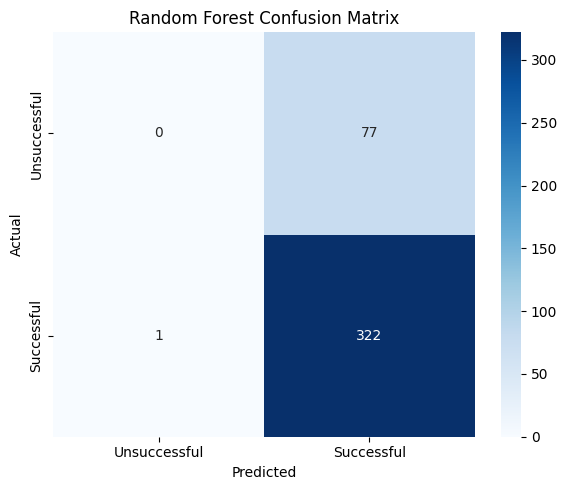

In [33]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Unsuccessful", "Successful"],
    yticklabels=["Unsuccessful", "Successful"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("assets/confusion_matrix.png", dpi=300)
plt.show()

### Model Evaluation

The Random Forest model produced the following results:

- **Accuracy:** 80.5%
- **Precision:** 80.7%
- **Recall:** 99.69%

The confusion matrix was:

- **True Negatives:** 0
- **False Positives:** 77
- **False Negatives:** 1
- **True Positives:** 322

Although the model achieves an accuracy of 80.5% and very high recall for successful movies, it performs poorly at identifying unsuccessful movies.

The model correctly predicted 322 successful movies and missed only 1 successful movie. However, all 77 unsuccessful movies were incorrectly predicted as successful.

Therefore, the model is strongly biased toward predicting the majority class (successful movies). The high accuracy should be interpreted carefully because approximately 80.7% of the original dataset consists of successful movies.

The model's biggest weakness is identifying unsuccessful movies.

In [34]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("Feature Importance:")
print(feature_importance.round(4))

Feature Importance:
popularity      0.2621
budget          0.2589
vote_average    0.2557
runtime         0.2232
dtype: float64


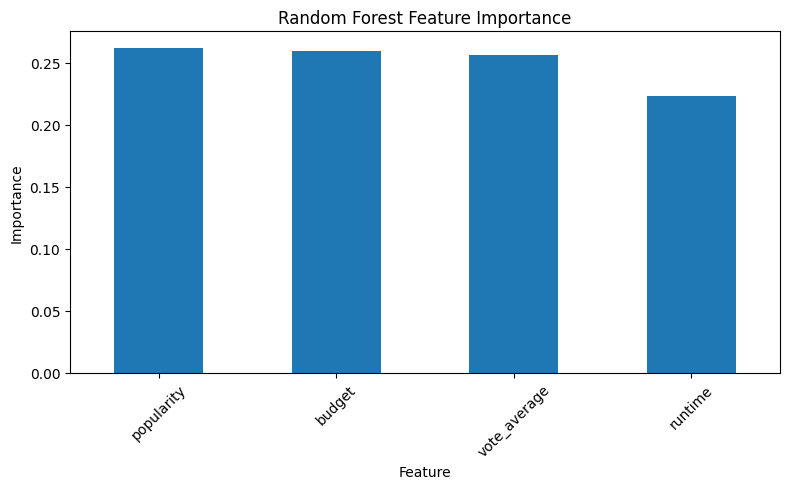

In [35]:
plt.figure(figsize=(8, 5))

feature_importance.plot(kind="bar")

plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("assets/feature_importance.png", dpi=300)
plt.show()

### Feature Importance Analysis

The Random Forest model produced the following feature importance scores:

- **Popularity:** 26.21%
- **Budget:** 25.89%
- **Vote Average:** 25.57%
- **Runtime:** 22.32%

Popularity is the most important feature in the model, followed closely by budget and vote average. Runtime has the lowest importance, although the differences between all four features are relatively small.

This partly agrees with the EDA and statistical testing. During EDA, popularity showed the clearest difference between successful and unsuccessful movies. The T-Test also found a statistically significant difference in popularity (p = 0.039682).

However, feature importance does not mean that a feature alone strongly predicts success. The model evaluation showed that the Random Forest had difficulty identifying unsuccessful movies.

In [36]:
import joblib

joblib.dump(model, "model.pkl")

print("Model saved successfully as model.pkl")

Model saved successfully as model.pkl


# Reflection

If a studio asked, "Will our next film succeed?", I would use MovieIQ as a decision-support tool rather than giving a completely certain answer.

Although the Random Forest achieved 80.5% accuracy, the confusion matrix showed that the model struggled to identify unsuccessful movies. It predicted almost all movies as successful because the dataset is imbalanced.

One limitation is that the model uses only a small number of features such as budget, popularity, runtime, and vote average.

With more time, I would improve the model by adding useful features such as cast, director, release date, marketing expenditure, and encoded genre information. I would also explore methods for handling class imbalance and compare Random Forest with other classification algorithms.